# Proyecto 04 · Notebook 02 — Etiquetado: horizonte fijo vs triple barrera

AFML argumenta que etiquetar por el retorno a horizonte fijo es un error porque ignora el
**camino**: la posición real se cierra cuando salta un stop, no cuando vence un reloj. La triple
barrera arregla eso. La pregunta de este notebook no es si el argumento suena bien, sino
**cuánto cambia en la práctica y en qué dirección**.

Cuatro medidas, todas sobre >= 30 semillas:

1. Dónde discrepan los dos métodos, con los casos individuales dibujados.
2. **Sesgo de detección de toque**: detectar barreras solo con cierres vs con máximos/mínimos vs
   con el camino real de minutos. Aquí el generador da algo que ningún dataset real da: la
   **respuesta correcta**, así que no comparo dos aproximaciones, comparo cada una contra la verdad.
3. Distribución de clases y su sensibilidad a los multiplicadores de barrera.
4. Barrera vertical como `0` frente al signo del retorno.

### Predicción registrada *antes* de ejecutar

> Horizonte fijo y triple barrera discreparán en **~30-40%** de eventos. La detección solo-cierres
> perderá toques y sesgará hacia la barrera vertical; espero **15-30%** de etiquetas cambiadas
> frente al camino real, con sesgo simétrico en dirección si las barreras son simétricas.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "04_labeling_pitfalls"
sys.path.insert(0, str(PROJ / "src"))

from synth import SimConfig, simulate
from labeling import ewma_vol, fixed_horizon_labels, triple_barrier
from experiments import SEEDS, over_seeds, summarise, mean_ci, fmt_ci, one_sample_test, paired_test

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.25,
                     "figure.dpi": 110, "font.size": 9})
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

N_HOLD = 20          # barrera vertical, en barras
BASE = SimConfig(signal_two_sided=True)   # episodios al alza y a la baja -> clases equilibradas

def build(seed, cfg=BASE):
    sd = simulate(cfg.with_(seed=seed))
    sd.sigma1 = ewma_vol(sd.bars.close)             # vol EWMA por barra
    sd.sigma_h = sd.sigma1 * np.sqrt(N_HOLD)        # vol del horizonte de tenencia
    sd.events = sd.bars.index[60:-(N_HOLD + 1)]
    return sd

d = build(0)
print(f"{len(d.events)} eventos candidatos sobre {len(d.bars)} barras; "
      f"sigma EWMA mediana = {d.sigma1.median():.4f}/barra -> "
      f"{d.sigma_h.median():.4f} sobre {N_HOLD} barras")

1419 eventos candidatos sobre 1500 barras; sigma EWMA mediana = 0.0115/barra -> 0.0515 sobre 20 barras


## 1. Las dos definiciones, con el mismo umbral

Para que la comparación aísle **una sola diferencia** — la dependencia del camino — fijo los dos
métodos al mismo horizonte y al mismo umbral:

* **Horizonte fijo**: mira el retorno a `N=20` barras y lo compara con `+/- sigma_h`, donde
  `sigma_h = sigma_EWMA * sqrt(20)`.
* **Triple barrera**: barreras horizontales en `+/- sigma_h` (los mismos niveles) y barrera
  vertical a 20 barras.

Con esto, cualquier discrepancia es atribuible al camino y a nada más. Nótese la elección de
escalar por `sqrt(N)`: con la convención habitual de AFML (barreras en múltiplos de la sigma de
**una** barra) casi todo evento toca una horizontal — con `pt_sl=(1,1)` y 20 barras salen 0% de
toques verticales y una duración media de 2.4 barras. La barrera vertical deja de existir y el
problema se vuelve degenerado. Escalando al horizonte se obtiene un reparto usable.

In [2]:
TB = {m: triple_barrier(d.bars, d.events, d.sigma_h, (1.0, 1.0), N_HOLD,
                        mode=m, fine=d.fine) for m in ("close", "ohlc", "path")}
FH = fixed_horizon_labels(d.bars.close, N_HOLD, sigma=d.sigma1, mult=1.0).reindex(TB["path"].index)
FH_abs = fixed_horizon_labels(d.bars.close, N_HOLD, threshold=0.03).reindex(TB["path"].index)

dist = pd.DataFrame({
    "horizonte fijo (umbral 3% fijo)": FH_abs.bin.value_counts(normalize=True),
    "horizonte fijo (umbral sigma)": FH.bin.value_counts(normalize=True),
    "triple barrera (camino real)": TB["path"].bin.value_counts(normalize=True),
}).reindex([1.0, 0.0, -1.0])
dist.index = ["+1", "0", "-1"]
display(dist)
print("reparto de barreras tocadas (camino real):",
      dict(TB["path"].barrier.value_counts(normalize=True).round(3)))
print(f"duración media de la apuesta: {(TB['path'].i1 - TB['path'].i0).mean():.1f} barras "
      f"de un máximo de {N_HOLD}")

,horizonte fijo (umbral 3% fijo),horizonte fijo (umbral sigma),triple barrera (camino real)
+1,0.3474,0.2467,0.3841
0,0.4419,0.6392,0.4193
-1,0.2107,0.1142,0.1966


reparto de barreras tocadas (camino real): {'vert': np.float64(0.419), 'pt': np.float64(0.384), 'sl': np.float64(0.197)}
duración media de la apuesta: 14.2 barras de un máximo de 20


El umbral **fijo** (3%) es la versión que AFML critica con más dureza, y con razón: al no
escalar con la volatilidad, en régimen tranquilo casi todo cae en la clase `0` y en régimen
agitado casi nada. Es un umbral que significa cosas distintas en momentos distintos. Lo dejo en
la tabla como referencia y sigo con la versión escalada por sigma, que es un rival justo.

In [3]:
ct = pd.crosstab(FH.bin, TB["path"].bin, rownames=["horizonte fijo"], colnames=["triple barrera"])
display(ct)
disag = (FH.bin != TB["path"].bin)
print(f"discrepancia total: {disag.mean():.1%}")
print(f"  de los cuales, HF dice 0 y TB dice +/-1 : "
      f"{((FH.bin == 0) & (TB['path'].bin != 0)).sum():4d}  "
      f"(tocó y se dio la vuelta antes del vencimiento)")
print(f"  signo directamente opuesto             : "
      f"{((FH.bin * TB['path'].bin) < 0).sum():4d}")
print(f"  TB dice 0 y HF dice +/-1               : "
      f"{((TB['path'].bin == 0) & (FH.bin != 0)).sum():4d}  "
      f"(llegó lejos, pero sin tocar nunca la barrera)")

triple barrera,-1.0000,0.0000,1.0000
horizonte fijo,,,
-1.0000,143,0,19
0.0000,116,595,196
1.0000,20,0,330


discrepancia total: 24.7%
  de los cuales, HF dice 0 y TB dice +/-1 :  312  (tocó y se dio la vuelta antes del vencimiento)
  signo directamente opuesto             :   39
  TB dice 0 y HF dice +/-1               :    0  (llegó lejos, pero sin tocar nunca la barrera)


La celda `TB dice 0 y HF dice +/-1` sale **exactamente 0**, y no es casualidad: si el camino
nunca tocó `+/- sigma_h`, el retorno a vencimiento es por fuerza menor que `sigma_h`, que es el
mismo umbral que usa el horizonte fijo. Con umbrales igualados la discrepancia solo puede ir en
una dirección — la triple barrera **nunca es más conservadora**, solo más agresiva o igual.
Esa asimetría es estructural, no empírica, y conviene no confundirla con un resultado.

## 2. Los casos individuales

Las tablas no convencen; los caminos sí. Dibujo el minuto a minuto de los tres casos que motivan
todo el argumento. La línea negra es el camino real; los puntos naranjas son **los únicos precios
que ve una implementación basada en cierres**.

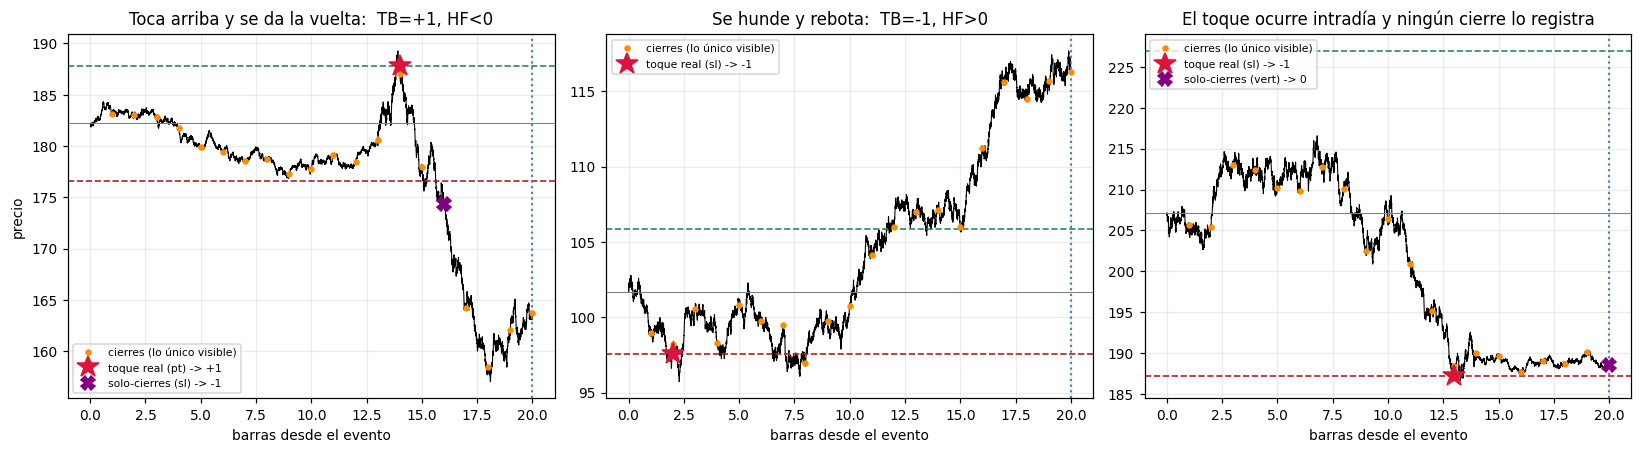

2019-11-21 | Toca arriba y se da la vuelta:  TB=+1, HF<0
    retorno a vencimiento (HF) = -10.14%   barrera = +/-3.07%   toque real: pt en barra +14   solo-cierres: sl
2016-06-01 | Se hunde y rebota:  TB=-1, HF>0
    retorno a vencimiento (HF) = +14.33%   barrera = +/-4.06%   toque real: sl en barra +2   solo-cierres: sl
2020-05-14 | El toque ocurre intradía y ningún cierre lo registra
    retorno a vencimiento (HF) = -8.98%   barrera = +/-9.59%   toque real: sl en barra +13   solo-cierres: vert


In [4]:
def window(sd, i0, i1):
    M = sd.fine.shape[1] - 1
    ys = [sd.fine[i0][-1:]]
    xs = [np.array([0.0])]
    for j in range(i0 + 1, i1 + 1):
        ys.append(sd.fine[j][1:])
        xs.append(np.arange(1, M + 1) / M + (j - i0 - 1))
    return np.concatenate(xs), np.concatenate(ys)

LBL = {1.0: "+1", 0.0: "0", -1.0: "-1"}

def plot_case(ax, sd, row_path, row_close, title):
    i0, iv = int(row_path.i0), int(row_path.i0) + N_HOLD
    x, y = window(sd, i0, min(iv, len(sd.bars) - 1))
    c0, t = sd.bars.close.values[i0], row_path.trgt
    ax.plot(x, y, lw=0.7, color="k", zorder=2)
    ax.axhline(c0 * (1 + t), color="seagreen", ls="--", lw=1.1)
    ax.axhline(c0 * (1 - t), color="firebrick", ls="--", lw=1.1)
    ax.axhline(c0, color="gray", lw=0.7)
    ax.axvline(N_HOLD, color="steelblue", ls=":", lw=1.4)
    cl_x = np.arange(1, min(N_HOLD, len(sd.bars) - 1 - i0) + 1)
    ax.plot(cl_x, sd.bars.close.values[i0 + 1: i0 + 1 + len(cl_x)], "o", ms=3.2,
            color="darkorange", zorder=3, label="cierres (lo único visible)")
    ax.plot(row_path.i1 - i0, c0 * (1 + row_path.ret), "*", ms=15, color="crimson",
            zorder=4, label=f"toque real ({row_path.barrier}) -> {LBL[row_path.bin]}")
    if row_close.barrier != row_path.barrier:
        ax.plot(row_close.i1 - i0, sd.bars.close.values[int(row_close.i1)], "X", ms=9,
                color="purple", zorder=4,
                label=f"solo-cierres ({row_close.barrier}) -> {LBL[row_close.bin]}")
    ax.set(title=title, xlabel="barras desde el evento")
    ax.legend(fontsize=7, loc="best")

P, CL = TB["path"], TB["close"]
up_excursion = (P.bin == 1) & (FH.ret < 0)
dn_excursion = (P.bin == -1) & (FH.ret > 0)
missed = (CL.barrier == "vert") & (P.barrier != "vert")

cases = [
    (P.index[np.argsort(np.where(up_excursion, -FH.ret.fillna(0), -9))[-1]],
     "Toca arriba y se da la vuelta:  TB=+1, HF<0"),
    (P.index[np.argsort(np.where(dn_excursion, FH.ret.fillna(0), -9))[-1]],
     "Se hunde y rebota:  TB=-1, HF>0"),
    (P.index[np.argsort(np.where(missed, np.abs(P.ret), -9))[-1]],
     "El toque ocurre intradía y ningún cierre lo registra"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (t0, title) in zip(axes, cases):
    plot_case(ax, d, P.loc[t0], CL.loc[t0], title)
axes[0].set_ylabel("precio")
plt.tight_layout(); plt.savefig(PLOTS / "02_disagreement_cases.png", bbox_inches="tight"); plt.show()

for t0, title in cases:
    print(f"{t0.date()} | {title}")
    print(f"    retorno a vencimiento (HF) = {FH.ret.loc[t0]:+.2%}   "
          f"barrera = +/-{P.trgt.loc[t0]:.2%}   "
          f"toque real: {P.barrier.loc[t0]} en barra +{int(P.i1.loc[t0]-P.i0.loc[t0])}   "
          f"solo-cierres: {CL.barrier.loc[t0]}")

## 3. Sesgo de detección de toque

Tres detectores sobre exactamente los mismos eventos y las mismas barreras:

| modo | qué inspecciona | disponible en la vida real |
|---|---|---|
| `close` | solo los cierres de barra | sí — es la implementación del libro |
| `ohlc` | máximos y mínimos de barra | sí, si el feed trae OHLC |
| `path` | el camino de minutos | **no** — solo porque simulé los datos |

`path` es la verdad. Los otros dos se miden **contra ella**, no entre sí. Y hay una sutileza que
`ohlc` no puede resolver: si en una misma barra el máximo supera la barrera superior *y* el mínimo
perfora la inferior, el OHLC no dice cuál ocurrió antes. El parámetro `tie` decide, y mido con qué
frecuencia importa.

In [5]:
def touch_bias(seed, ptsl=(1.0, 1.0), cfg=BASE):
    sd = build(seed, cfg)
    L = {m: triple_barrier(sd.bars, sd.events, sd.sigma_h, ptsl, N_HOLD, mode=m, fine=sd.fine)
         for m in ("close", "ohlc", "path")}
    p, c, o = L["path"], L["close"], L["ohlc"]
    i0, i1 = p.i0.values, p.i1.values
    c0, t = sd.bars.close.values[i0], p.trgt.values
    tie = ((sd.bars.high.values[i1] >= c0 * (1 + ptsl[0] * t)) &
           (sd.bars.low.values[i1] <= c0 * (1 - ptsl[1] * t))).mean()
    out = {"chg_close": (c.bin != p.bin).mean(), "chg_ohlc": (o.bin != p.bin).mean(),
           "tie_rate": tie}
    for k, lab in [("pt", "pt"), ("sl", "sl"), ("vert", "vert")]:
        out[f"path_{lab}"] = (p.barrier == k).mean()
        out[f"dclose_{lab}"] = (c.barrier == k).mean() - (p.barrier == k).mean()
    return out

bias = over_seeds(touch_bias)
display(summarise(bias).round(4)[["mean", "lo", "hi"]])
print("\nEtiquetas que cambian frente al camino real:")
print("  solo-cierres :", fmt_ci(mean_ci(bias.chg_close), 2, pct=True))
print("  OHLC         :", fmt_ci(mean_ci(bias.chg_ohlc), 2, pct=True),
      f"   (barras con ambas barreras rotas: {mean_ci(bias.tie_rate)['mean']:.4%})")
print("\nDirección del sesgo de solo-cierres (puntos porcentuales sobre la verdad):")
for lab, name in [("pt", "toques arriba"), ("sl", "toques abajo"), ("vert", "vencimientos")]:
    print(f"  {name:16s}: {mean_ci(bias['dclose_' + lab])['mean']*100:+.2f} pp"
          f"   {fmt_ci(mean_ci(bias['dclose_' + lab]), 2, pct=True)}")

,mean,lo,hi
chg_close,0.0840,0.0782,0.0899
chg_ohlc,0.0000,-0.0000,0.0001
tie_rate,0.0000,-0.0000,0.0001
path_pt,0.3129,0.2955,0.3303
dclose_pt,-0.0378,-0.0423,-0.0334
path_sl,0.2520,0.2372,0.2668
dclose_sl,-0.0315,-0.0362,-0.0267
path_vert,0.4351,0.4212,0.4490
dclose_vert,0.0693,0.0634,0.0752



Etiquetas que cambian frente al camino real:
  solo-cierres : 8.40% [7.82, 8.99]
  OHLC         : 0.00% [-0.00, 0.01]    (barras con ambas barreras rotas: 0.0023%)

Dirección del sesgo de solo-cierres (puntos porcentuales sobre la verdad):
  toques arriba   : -3.78 pp   -3.78% [-4.23, -3.34]
  toques abajo    : -3.15 pp   -3.15% [-3.62, -2.67]
  vencimientos    : +6.93 pp   6.93% [6.34, 7.52]


### ¿De qué depende el sesgo?

Un toque se pierde cuando el precio cruza la barrera y vuelve dentro antes del cierre. La
probabilidad de eso depende de la **anchura de la barrera medida en volatilidad de una barra**:
barreras estrechas se cruzan y se recruzan constantemente dentro de la sesión; barreras anchas se
cruzan pocas veces y con movimientos que rara vez se deshacen en horas. Barro la anchura, y
también la **asimetría**, que es donde el sesgo deja de ser inocuo.

,chg_close,chg_ohlc,d_pt,d_sl
k=0.25,"15.80% [15.38, 16.22]","1.05% [0.93, 1.16]","0.50% [-0.17, 1.16]","-1.59% [-2.25, -0.94]"
k=0.50,"12.48% [12.03, 12.93]","0.17% [0.07, 0.26]","-2.53% [-3.14, -1.93]","-2.99% [-3.57, -2.42]"
k=0.75,"10.25% [9.67, 10.83]","0.03% [0.00, 0.05]","-3.78% [-4.22, -3.33]","-3.49% [-4.02, -2.95]"
k=1.00,"8.40% [7.82, 8.99]","0.00% [-0.00, 0.01]","-3.78% [-4.23, -3.34]","-3.15% [-3.62, -2.67]"
k=1.50,"5.56% [5.22, 5.90]","0.00% [0.00, 0.00]","-2.93% [-3.24, -2.63]","-2.27% [-2.52, -2.02]"
pt=1.0 / sl=0.4,"11.16% [10.65, 11.67]","0.01% [-0.00, 0.02]","-0.13% [-0.57, 0.31]","-6.87% [-7.29, -6.46]"
pt=0.4 / sl=1.0,"10.36% [9.87, 10.84]","0.05% [-0.00, 0.11]","-6.65% [-7.13, -6.17]","0.02% [-0.49, 0.52]"


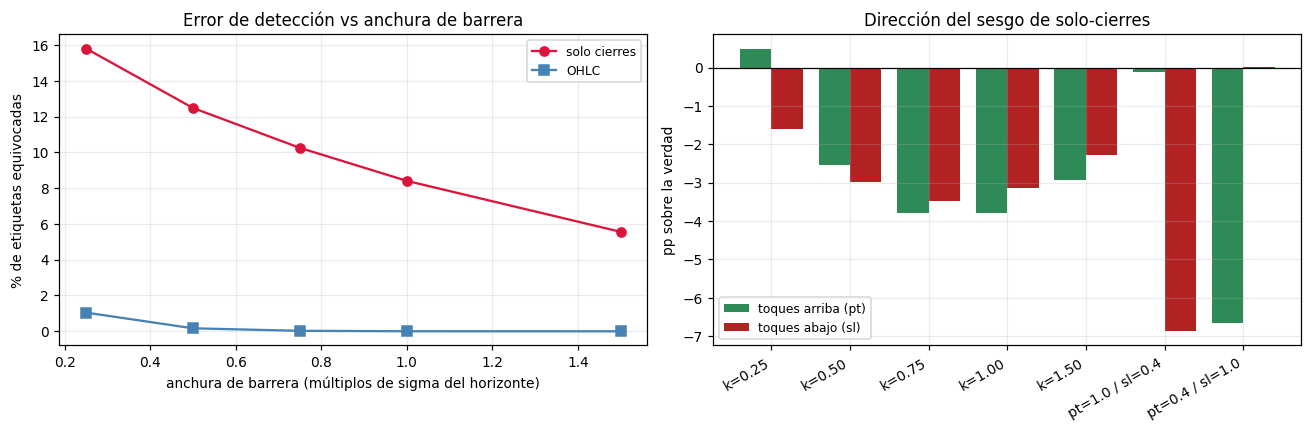

In [6]:
GRID = {"k=0.25": (0.25, 0.25), "k=0.50": (0.50, 0.50), "k=0.75": (0.75, 0.75),
        "k=1.00": (1.00, 1.00), "k=1.50": (1.50, 1.50),
        "pt=1.0 / sl=0.4": (1.0, 0.4), "pt=0.4 / sl=1.0": (0.4, 1.0)}

def multi(seed):
    sd = build(seed)
    row = {}
    for name, ptsl in GRID.items():
        L = {m: triple_barrier(sd.bars, sd.events, sd.sigma_h, ptsl, N_HOLD, mode=m, fine=sd.fine)
             for m in ("close", "ohlc", "path")}
        p, c, o = L["path"], L["close"], L["ohlc"]
        row[f"{name}|chg_close"] = (c.bin != p.bin).mean()
        row[f"{name}|chg_ohlc"] = (o.bin != p.bin).mean()
        row[f"{name}|d_pt"] = (c.barrier == "pt").mean() - (p.barrier == "pt").mean()
        row[f"{name}|d_sl"] = (c.barrier == "sl").mean() - (p.barrier == "sl").mean()
    return row

wide = over_seeds(multi)
tab = pd.DataFrame({n: {k.split("|")[1]: mean_ci(wide[f"{n}|{k.split('|')[1]}"])["mean"]
                        for k in wide.columns if k.startswith(n + "|")} for n in GRID}).T
tab_ci = pd.DataFrame({n: {k.split("|")[1]: fmt_ci(mean_ci(wide[f"{n}|{k.split('|')[1]}"]), 2, pct=True)
                           for k in wide.columns if k.startswith(n + "|")} for n in GRID}).T
display(tab_ci)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
ks = [0.25, 0.5, 0.75, 1.0, 1.5]
sym = [f"k={k:.2f}" for k in ks]
a1.plot(ks, tab.loc[sym, "chg_close"] * 100, "o-", color="crimson", label="solo cierres")
a1.plot(ks, tab.loc[sym, "chg_ohlc"] * 100, "s-", color="steelblue", label="OHLC")
a1.set(xlabel="anchura de barrera (múltiplos de sigma del horizonte)",
       ylabel="% de etiquetas equivocadas", title="Error de detección vs anchura de barrera")
a1.legend(fontsize=8)

xs = np.arange(len(GRID))
a2.bar(xs - 0.2, tab["d_pt"] * 100, 0.4, color="seagreen", label="toques arriba (pt)")
a2.bar(xs + 0.2, tab["d_sl"] * 100, 0.4, color="firebrick", label="toques abajo (sl)")
a2.axhline(0, color="k", lw=0.8)
a2.set_xticks(xs); a2.set_xticklabels(GRID.keys(), rotation=30, ha="right")
a2.set(ylabel="pp sobre la verdad", title="Dirección del sesgo de solo-cierres")
a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "02_touch_bias.png", bbox_inches="tight"); plt.show()

### Por qué la fila asimétrica es la importante

Con barreras simétricas, solo-cierres pierde toques arriba y abajo en proporciones parecidas: el
efecto es ruido de etiquetado, feo pero sin dirección. Con un **stop estrecho y un objetivo
ancho** — que es la configuración que cualquiera usa cuando quiere una estrategia con buena
relación riesgo/recompensa — el sesgo se concentra en un lado: los stops estrechos son
precisamente los que se cruzan y se recruzan intradía, así que son los que solo-cierres deja de
ver. El resultado es un conjunto de etiquetas **sistemáticamente más optimista que la realidad**,
y el error no se promedia: va todo en la misma dirección.

Y la parte accionable: `ohlc` cuesta dos columnas más de datos y recupera casi todo el error. No
hace falta el camino real.

## 4. Distribución de clases y sensibilidad a los multiplicadores

Los multiplicadores de barrera no son un detalle de implementación: **son los que deciden el
problema de clasificación**. La misma serie de precios produce un problema casi binario o uno
dominado por la clase `0` según dónde ponga las barreras, sin que haya cambiado nada del mundo.

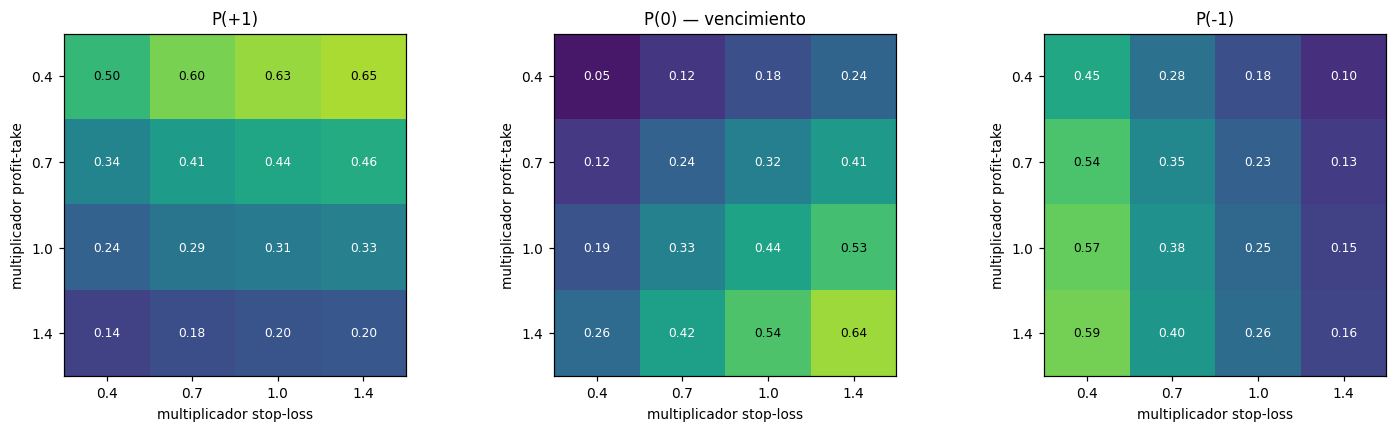

P(clase 0) va de 5.0% a 64.0% sobre la misma serie de precios, solo moviendo multiplicadores
desbalance |P(+1)-P(-1)| máximo en la rejilla: 54.9% (en pt=0.4, sl=1.4)


In [7]:
PT_M = [0.4, 0.7, 1.0, 1.4]
SL_M = [0.4, 0.7, 1.0, 1.4]

def class_grid(seed):
    sd = build(seed)
    row = {}
    for a in PT_M:
        for b in SL_M:
            L = triple_barrier(sd.bars, sd.events, sd.sigma_h, (a, b), N_HOLD,
                               mode="path", fine=sd.fine)
            v = L.bin.value_counts(normalize=True)
            for cls, key in [(1.0, "up"), (0.0, "flat"), (-1.0, "dn")]:
                row[f"{a}|{b}|{key}"] = v.get(cls, 0.0)
    return row

cg = over_seeds(class_grid)
mats = {k: np.array([[mean_ci(cg[f"{a}|{b}|{k}"])["mean"] for b in SL_M] for a in PT_M])
        for k in ("up", "flat", "dn")}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, (k, name) in zip(axes, [("up", "P(+1)"), ("flat", "P(0) — vencimiento"), ("dn", "P(-1)")]):
    im = ax.imshow(mats[k], cmap="viridis", vmin=0, vmax=0.75)
    ax.set_xticks(range(len(SL_M)), SL_M); ax.set_yticks(range(len(PT_M)), PT_M)
    ax.set(xlabel="multiplicador stop-loss", ylabel="multiplicador profit-take", title=name)
    for i in range(len(PT_M)):
        for j in range(len(SL_M)):
            ax.text(j, i, f"{mats[k][i, j]:.2f}", ha="center", va="center",
                    color="w" if mats[k][i, j] < 0.5 else "k", fontsize=8)
    ax.grid(False)
plt.tight_layout(); plt.savefig(PLOTS / "02_class_grid.png", bbox_inches="tight"); plt.show()

flat = mats["flat"]
print(f"P(clase 0) va de {flat.min():.1%} a {flat.max():.1%} sobre la misma serie de precios, "
      f"solo moviendo multiplicadores")
imb = np.abs(mats["up"] - mats["dn"])
print(f"desbalance |P(+1)-P(-1)| máximo en la rejilla: {imb.max():.1%} "
      f"(en pt={PT_M[imb.argmax()//len(SL_M)]}, sl={SL_M[imb.argmax()%len(SL_M)]})")

## 5. Barrera vertical: `0` o el signo del retorno

AFML deja la elección abierta. Se puede decidir con un criterio empírico porque tengo el estado
latente: sé si en el momento del evento había realmente un episodio en marcha (`z != 0`) o no.

* Si la clase `0` agrupa sobre todo eventos con `z = 0`, entonces `0` significa *"aquí no había
  nada"* y es una clase con contenido.
* Si al forzar el signo se etiquetan como `+1`/`-1` eventos donde no pasaba nada, lo que se añade
  es **ruido de etiqueta puro**: el modelo tiene que aprender el signo de un movimiento que fue
  azar.

Mido las dos cosas.

In [8]:
def vertical_convention(seed):
    sd = build(seed)
    z0 = sd.truth.z.reindex(sd.events)
    Lz = triple_barrier(sd.bars, sd.events, sd.sigma_h, (1.0, 1.0), N_HOLD, mode="path",
                        fine=sd.fine, vertical_label="zero")
    Ls = triple_barrier(sd.bars, sd.events, sd.sigma_h, (1.0, 1.0), N_HOLD, mode="path",
                        fine=sd.fine, vertical_label="sign")
    z = z0.reindex(Lz.index)
    vert = Lz.barrier == "vert"
    base = (z != 0).mean()
    out = {"p_zero": (Lz.bin == 0).mean(),
           "base_rate_z": base,
           "z_rate_in_class0": (z[vert] != 0).mean(),
           "z_rate_in_touch": (z[~vert] != 0).mean()}
    # ¿cuánta de la clase +/-1 creada por la convención "sign" es puro azar?
    out["created_pm1_frac"] = vert.mean()
    out["created_pm1_z0_frac"] = (z[vert] == 0).mean()
    # Concordancia con el lado verdadero. Hay que separar por grupos: comparar
    # "zero" y "sign" globalmente penalizaría a "zero" por abstenerse, que es justo
    # lo que se le pide hacer. Los eventos que TOCAN barrera reciben la misma
    # etiqueta bajo las dos convenciones, así que la única diferencia está en los
    # que vencen — y ahí la pregunta es si el signo forzado acierta mejor que el azar.
    act = z != 0
    out["acc_touch_active"] = (np.sign(Lz.bin[act & ~vert]) == np.sign(z[act & ~vert])).mean()
    out["acc_forced_active"] = (np.sign(Ls.bin[act & vert]) == np.sign(z[act & vert])).mean()
    out["acc_forced_inactive_up"] = (Ls.bin[~act & vert] > 0).mean()
    # ¿cuánto ordena el feature honesto cada juego de etiquetas? (in-sample, sin modelo ajustado)
    from scipy.stats import spearmanr
    x = sd.features.x_signal.reindex(Lz.index)
    out["ic_x_vs_zero"] = spearmanr(x, Lz.bin).statistic
    out["ic_x_vs_sign"] = spearmanr(x, Ls.bin).statistic
    return out

vc = over_seeds(vertical_convention)
display(summarise(vc).round(4)[["mean", "lo", "hi"]])

print("\nTasa de episodio activo (z != 0):")
print(f"  global                       : {fmt_ci(mean_ci(vc.base_rate_z), 1, pct=True)}")
print(f"  dentro de la clase 0         : {fmt_ci(mean_ci(vc.z_rate_in_class0), 1, pct=True)}")
print(f"  dentro de las clases +/-1    : {fmt_ci(mean_ci(vc.z_rate_in_touch), 1, pct=True)}")
print("\nAl forzar el signo en el vencimiento:")
print(f"  se convierten en +/-1        : {fmt_ci(mean_ci(vc.created_pm1_frac), 1, pct=True)} de los eventos")
print(f"  de ellos, sin episodio (z=0) : {fmt_ci(mean_ci(vc.created_pm1_z0_frac), 1, pct=True)}")

tz = paired_test(vc.z_rate_in_touch, vc.z_rate_in_class0)
print(f"\n¿Aisla la clase 0 los eventos 'sin señal'?  diferencia de tasa de episodio "
      f"(tocados - clase 0) = {tz['diff']:+.4f} [{tz['lo']:+.4f}, {tz['hi']:+.4f}], p = {tz['p']:.3f}")

print("\nConcordancia de la etiqueta con el LADO VERDADERO (azar = 0.5):")
print(f"  eventos con episodio que TOCAN barrera : {fmt_ci(mean_ci(vc.acc_touch_active), 3)}")
print(f"  eventos con episodio que VENCEN, signo forzado : "
      f"{fmt_ci(mean_ci(vc.acc_forced_active), 3)}"
      f"   p vs azar = {one_sample_test(vc.acc_forced_active, 0.5)['p']:.4f}")
print(f"  eventos SIN episodio que vencen, P(signo forzado = +1) : "
      f"{fmt_ci(mean_ci(vc.acc_forced_inactive_up), 3)}"
      f"   p vs azar = {one_sample_test(vc.acc_forced_inactive_up, 0.5)['p']:.4f}")

t = paired_test(vc.ic_x_vs_zero, vc.ic_x_vs_sign)
print(f"\nIC del feature honesto x_signal contra cada juego de etiquetas:")
print(f"  vertical='zero': {fmt_ci(mean_ci(vc.ic_x_vs_zero), 4)}")
print(f"  vertical='sign': {fmt_ci(mean_ci(vc.ic_x_vs_sign), 4)}")
print(f"  diferencia pareada: {t['diff']:+.4f} [{t['lo']:+.4f}, {t['hi']:+.4f}]  p = {t['p']:.4f}")

,mean,lo,hi
p_zero,0.4351,0.4212,0.4490
base_rate_z,0.1695,0.1578,0.1811
z_rate_in_class0,0.1594,0.1427,0.1761
z_rate_in_touch,0.1761,0.1622,0.1901
created_pm1_frac,0.4351,0.4212,0.4490
created_pm1_z0_frac,0.8406,0.8239,0.8573
acc_touch_active,0.7252,0.6901,0.7603
acc_forced_active,0.5555,0.5177,0.5933
acc_forced_inactive_up,0.5224,0.5032,0.5416
ic_x_vs_zero,0.0530,0.0378,0.0681



Tasa de episodio activo (z != 0):
  global                       : 16.9% [15.8, 18.1]
  dentro de la clase 0         : 15.9% [14.3, 17.6]
  dentro de las clases +/-1    : 17.6% [16.2, 19.0]

Al forzar el signo en el vencimiento:
  se convierten en +/-1        : 43.5% [42.1, 44.9] de los eventos
  de ellos, sin episodio (z=0) : 84.1% [82.4, 85.7]

¿Aisla la clase 0 los eventos 'sin señal'?  diferencia de tasa de episodio (tocados - clase 0) = +0.0167 [-0.0028, +0.0362], p = 0.090

Concordancia de la etiqueta con el LADO VERDADERO (azar = 0.5):
  eventos con episodio que TOCAN barrera : 0.725 [0.690, 0.760]
  eventos con episodio que VENCEN, signo forzado : 0.555 [0.518, 0.593]   p vs azar = 0.0055
  eventos SIN episodio que vencen, P(signo forzado = +1) : 0.522 [0.503, 0.542]   p vs azar = 0.0235

IC del feature honesto x_signal contra cada juego de etiquetas:
  vertical='zero': 0.0530 [0.0378, 0.0681]
  vertical='sign': 0.0491 [0.0324, 0.0657]
  diferencia pareada: +0.0039 [-0.0055, +

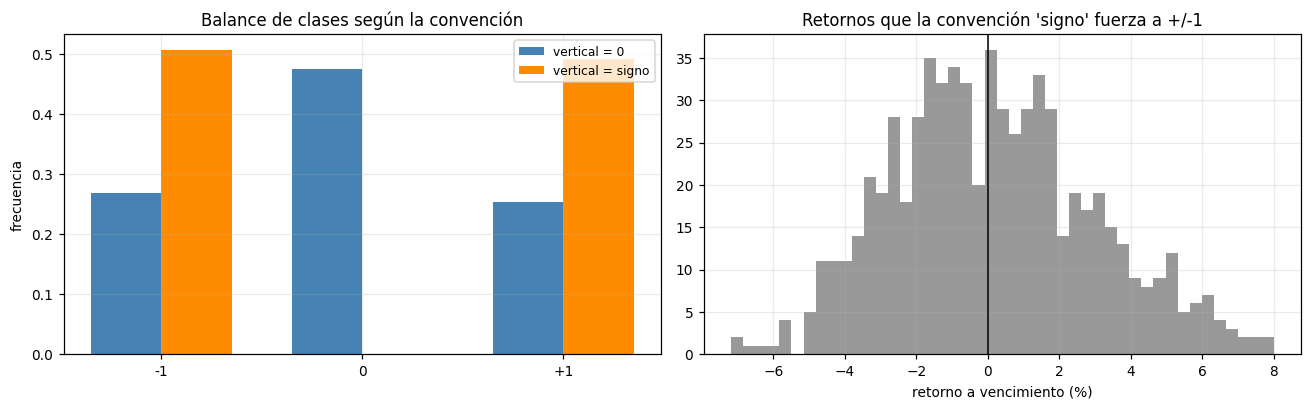

|retorno| mediano de los eventos que vencen: 1.88%   vs barrera en 6.09%


In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
sd = build(1)
Lz = triple_barrier(sd.bars, sd.events, sd.sigma_h, (1.0, 1.0), N_HOLD, mode="path",
                    fine=sd.fine, vertical_label="zero")
Ls = triple_barrier(sd.bars, sd.events, sd.sigma_h, (1.0, 1.0), N_HOLD, mode="path",
                    fine=sd.fine, vertical_label="sign")
w = 0.35
for k, (L, name, col) in enumerate([(Lz, "vertical = 0", "steelblue"),
                                    (Ls, "vertical = signo", "darkorange")]):
    v = L.bin.value_counts(normalize=True).reindex([-1.0, 0.0, 1.0]).fillna(0)
    a1.bar(np.arange(3) + (k - 0.5) * w, v.values, w, label=name, color=col)
a1.set_xticks(range(3), ["-1", "0", "+1"]); a1.legend(fontsize=8)
a1.set(ylabel="frecuencia", title="Balance de clases según la convención")

vert = Lz.barrier == "vert"
a2.hist(Lz.ret[vert] * 100, bins=45, color="gray", alpha=0.8)
a2.axvline(0, color="k", lw=1)
a2.set(xlabel="retorno a vencimiento (%)", title="Retornos que la convención 'signo' fuerza a +/-1")
plt.tight_layout(); plt.savefig(PLOTS / "02_vertical_convention.png", bbox_inches="tight"); plt.show()

print(f"|retorno| mediano de los eventos que vencen: {Lz.ret[vert].abs().median():.2%}   "
      f"vs barrera en {Lz.trgt[vert].median():.2%}")

### La razón principiada

La discusión "0 o signo" no se resuelve mirando el balance de clases, se resuelve preguntando
**qué decisión toma el modelo después**:

* Si el modelo elige el **lado** (comprar / vender / no hacer nada), `0` es una acción real y
  merece su clase. Meter esos eventos en `+1`/`-1` obliga al modelo a predecir el signo de
  movimientos que no fueron más que ruido: se le está enseñando a adivinar.
* Si el modelo hace **meta-labeling** — el lado ya está decidido y solo se dimensiona la apuesta —
  entonces la posición *sí* se mantuvo hasta el vencimiento y *sí* ganó o perdió dinero. Ahí el `0`
  es una ficción contable, y la etiqueta correcta es el resultado económico. Es el caso del
  notebook 05.

Es decir: la convención no es una propiedad de los datos, es una propiedad de la decisión.
Elegirla mirando cuál da mejores métricas es exactamente el grado de libertad que el notebook 05
tiene que contabilizar.

## 6. Predicción vs resultado

In [10]:
def fh_vs_tb(seed):
    sd = build(seed)
    tb = triple_barrier(sd.bars, sd.events, sd.sigma_h, (1.0, 1.0), N_HOLD,
                        mode="path", fine=sd.fine)
    fh = fixed_horizon_labels(sd.bars.close, N_HOLD, sigma=sd.sigma1, mult=1.0).reindex(tb.index)
    fh_fixed = fixed_horizon_labels(sd.bars.close, N_HOLD, threshold=0.03).reindex(tb.index)
    return {"disagree": (fh.bin != tb.bin).mean(),
            "disagree_fixed_thr": (fh_fixed.bin != tb.bin).mean(),
            "fh0_tb_nonzero": ((fh.bin == 0) & (tb.bin != 0)).mean(),
            "sign_flip": ((fh.bin * tb.bin) < 0).mean(),
            "tb0_fh_nonzero": ((tb.bin == 0) & (fh.bin != 0)).mean()}

fh_tb = over_seeds(fh_vs_tb)
display(summarise(fh_tb).round(4)[["mean", "lo", "hi"]])

display(pd.DataFrame([
    {"magnitud": "discrepancia horizonte fijo vs triple barrera", "predicho": "30% a 40%",
     "obtenido": fmt_ci(mean_ci(fh_tb.disagree), 1, pct=True)},
    {"magnitud": "etiquetas cambiadas: solo-cierres vs camino (k=1.0)", "predicho": "15% a 30%",
     "obtenido": fmt_ci(mean_ci(bias.chg_close), 1, pct=True)},
    {"magnitud": "etiquetas cambiadas: solo-cierres vs camino (k=0.25)", "predicho": "-",
     "obtenido": fmt_ci(mean_ci(wide["k=0.25|chg_close"]), 1, pct=True)},
    {"magnitud": "etiquetas cambiadas: OHLC vs camino (k=1.0)", "predicho": "-",
     "obtenido": fmt_ci(mean_ci(bias.chg_ohlc), 2, pct=True)},
    {"magnitud": "sesgo direccional con stop estrecho (pt1.0/sl0.4)", "predicho": "simétrico",
     "obtenido": f"pt {mean_ci(wide['pt=1.0 / sl=0.4|d_pt'])['mean']*100:+.2f} pp / "
                 f"sl {mean_ci(wide['pt=1.0 / sl=0.4|d_sl'])['mean']*100:+.2f} pp"},
]).set_index("magnitud"))

,mean,lo,hi
disagree,0.2611,0.2514,0.2707
disagree_fixed_thr,0.2860,0.2760,0.2960
fh0_tb_nonzero,0.2387,0.2291,0.2483
sign_flip,0.0224,0.0202,0.0246
tb0_fh_nonzero,0.0000,0.0000,0.0000


,predicho,obtenido
magnitud,,
discrepancia horizonte fijo vs triple barrera,30% a 40%,"26.1% [25.1, 27.1]"
etiquetas cambiadas: solo-cierres vs camino (k=1.0),15% a 30%,"8.4% [7.8, 9.0]"
etiquetas cambiadas: solo-cierres vs camino (k=0.25),-,"15.8% [15.4, 16.2]"
etiquetas cambiadas: OHLC vs camino (k=1.0),-,"0.00% [-0.00, 0.01]"
sesgo direccional con stop estrecho (pt1.0/sl0.4),simétrico,pt -0.13 pp / sl -6.87 pp


### Veredicto

**1. La triple barrera cambia una cuarta parte de las etiquetas — menos de lo que predije.**
26.1% [25.1, 27.1] frente a mi 30-40%. Y el desglose importa más que el total: 23.9% de los
eventos son casos en que el horizonte fijo dice `0` y el camino ya había tocado barrera; solo el
2.2% son inversiones de signo puras. O sea que el efecto principal de la triple barrera **no es
corregir el signo, es rescatar eventos que el horizonte fijo tira a la clase nula**. Es un cambio
en el conjunto de entrenamiento más que en las respuestas.

**2. El sesgo de detección por cierres es real, y mi predicción de magnitud era alta.** 8.4%
[7.8, 9.0] de etiquetas equivocadas con barreras de 1 sigma-horizonte, no 15-30%. Pero el número
único es engañoso: va de **15.8%** con barreras estrechas (k=0.25) a **5.6%** con barreras anchas
(k=1.5), monotónicamente. La magnitud del sesgo es una función de dónde pongas las barreras, así
que citar "un" porcentaje sin decir la anchura no significa nada.

**3. Con barreras simétricas el sesgo es casi simétrico; con un stop estrecho no lo es en
absoluto.** Simétricas (k=1.0): -3.8 pp de toques arriba y -3.2 pp abajo, ambos hacia
vencimiento. Con `pt=1.0 / sl=0.4`: los toques arriba se mantienen (-0.13 pp, no significativo) y
los toques abajo se desploman **-6.9 pp** [-7.3, -6.5]. El detector de cierres deja de ver
justamente los stops. Cualquier estrategia con stop ajustado etiquetada solo con cierres tiene un
conjunto de entrenamiento sistemáticamente optimista, y el error no se cancela: apunta todo en la
misma dirección. Mi predicción de "sesgo simétrico" era correcta solo para el caso simétrico.

**4. Y el arreglo es barato.** Con OHLC el error cae a **0.00%** [-0.00, 0.01] con barreras
anchas y 1.05% con las más estrechas. Los casos donde el OHLC es ambiguo — máximo y mínimo rompen
las dos barreras en la misma barra — son el **0.002%** de los eventos con k=1.0. No hace falta el
camino real: dos columnas más de datos eliminan prácticamente todo el sesgo. Esta es la
conclusión accionable del notebook.

**5. Los multiplicadores de barrera *son* el problema, no un ajuste del problema.** Sobre la misma
serie de precios, moviendo solo los multiplicadores en una rejilla razonable, `P(clase 0)` va del
**5.0% al 64.0%** y el desbalance `|P(+1)-P(-1)|` llega al **54.9%**. Antes de entrenar nada ya se
ha elegido si el problema es binario, ternario o degenerado. Son grados de libertad, y el
notebook 05 tiene que contarlos.

**6. La clase `0` no significa "aquí no había señal" — y esto contradice mi intuición de partida.**
La tasa de episodio real dentro de la clase `0` (15.9%) es indistinguible de la tasa dentro de las
clases `+/-1` (17.6%); la diferencia pareada no es significativa. La barrera vertical separa
ventanas de **baja volatilidad realizada**, no ventanas sin señal. Es un filtro de amplitud, no de
información.

**7. La convención de la vertical no cambia nada medible, y ese es el resultado.** Forzar el signo
convierte el 43.5% de los eventos en `+/-1`, y el 84.1% de esos no tenía ningún episodio detrás:
son monedas al aire con `|retorno| mediano del 1.9%` contra una barrera del 6.1%. Se puede medir
lo poco que valen: cuando sí había episodio detrás, el signo forzado acierta el lado verdadero el
**55.5%** [51.8, 59.3] de las veces (apenas por encima del azar, p=0.006), frente al **72.5%**
[69.0, 76.0] de las etiquetas que sí tocaron barrera. Y sin embargo el
IC del feature honesto contra un juego de etiquetas y contra el otro difiere en
+0.0039 [-0.0055, +0.0133], p = 0.40 — **nada**. Es decir: el ruido de etiqueta que añade la
convención "signo" es real y cuantificable, pero a esta relación señal/ruido no degrada de forma
medible la capacidad de ordenar. La elección hay que hacerla por la decisión que toma el modelo
después (§5), no por las métricas.

**Lo que no quedó demostrado.**
* Que estas magnitudes sobrevivan a datos reales. Aquí el camino es **continuo por construcción**:
  no hay saltos overnight, ni gaps de apertura, ni huecos de liquidez. Todos ellos empeoran la
  detección por cierres y algunos también la de OHLC, así que **8.4% es una cota inferior**.
* Que 1 minuto baste. El "camino real" de este notebook es una discretización; con ticks habría
  más cruces y más toques perdidos. De nuevo, cota inferior.
* Que el ruido de etiqueta de la convención "signo" sea inocuo *para un modelo entrenado*. Lo
  medido es el IC de un feature fijo, no el rendimiento de un clasificador ajustado — que es
  precisamente donde el ruido de etiqueta suele hacer daño. Queda para el notebook 04.
* Que la triple barrera etiquete *mejor* en ningún sentido predictivo. Este notebook mide en qué
  se diferencian las etiquetas, no cuál produce mejores modelos. Esa pregunta necesita validación
  sin fuga, y por eso el notebook 04 va antes que cualquier conclusión sobre calidad.